In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,r2_score

In [6]:
#Load dataset
housing=fetch_california_housing()
data=pd.DataFrame(housing.data,
                 columns=housing.feature_names)
data["price"]=housing.target

In [7]:
#select one feature
x=data[['AveRooms']].values
y=data['price'].values

In [8]:
#split data
x_train,x_test,y_train,y_test = train_test_split(
    x,y,
test_size=0.2,
random_state=42
)

In [9]:
#Feature Scaling
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [60]:
w=0
b=0
learning_rate=0.01
epochs=1000
cost_history=[]
n=len(x_train_scaled)
for i in range(epochs):
    y_pred=w*x_train_scaled.flatten()+b
    dw=(1/n)*np.sum((y_pred-y_train)*x_train_scaled.flatten())
    db=(1/n)*np.sum(y_pred-y_train)
    w=w-learning_rate*dw
    b=b-learning_rate*db
    cost=(1/(2*n))* np.sum((y_pred-y_train)**2)
    cost_history.append(cost)
    if i%100==0:
        print(f"Epoch {i}, cost={cost:.4f}")
y_pred_gd=w*x_test_scaled.flatten()+b

Epoch 0, cost=2.8149
Epoch 100, cost=0.9414
Epoch 200, cost=0.6904
Epoch 300, cost=0.6568
Epoch 400, cost=0.6523
Epoch 500, cost=0.6517
Epoch 600, cost=0.6516
Epoch 700, cost=0.6516
Epoch 800, cost=0.6516
Epoch 900, cost=0.6516


In [61]:
print("Gradient Descent")
print("-"*50)
print("Weight:",w)
print("bias:",b)
print("MSE:",mean_squared_error(y_test,y_pred_gd))
print("R2 Score:",r2_score(y_test,y_pred_gd))

Gradient Descent
--------------------------------------------------
Weight: 0.18323090648660517
bias: 2.0718574888450205
MSE: 1.292327655590046
R2 Score: 0.013798228607320828


In [62]:
#Normal equation
x_train_ne = np.c_[np.ones((len(x_train),1)), x_train]
x_test_ne=np.c_[np.ones((len(x_test),1)),x_test]
theta=np.linalg.inv(x_train_ne.T@x_train_ne)@x_train_ne.T@y_train
y_pred_ne=x_test_ne @ theta

In [63]:
print("\nNormal Equation")
print("------------")
print("Intercept:",theta[0])
print("slope:",theta[1])
print("MSE", mean_squared_error(y_test,y_pred_ne))
print("R2 Score:",r2_score(y_test,y_pred_ne))


Normal Equation
------------
Intercept: 1.6547622685968417
slope: 0.07675558963126736
MSE 1.2923314440807299
R2 Score: 0.013795337532284901


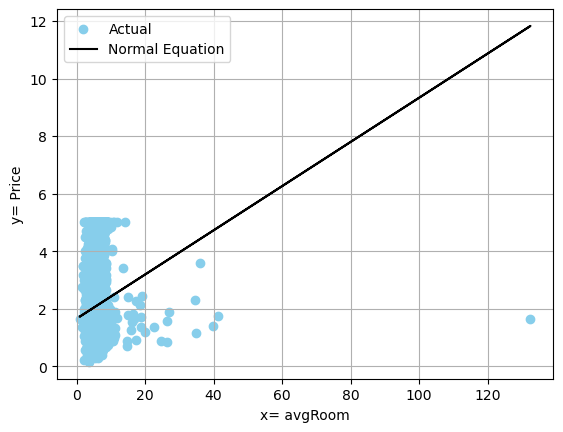

In [68]:
import matplotlib.pyplot as plt

for pred, color, style,label in [
    (y_pred_ne, "black","-","Normal Equation"),

]:
    plt.figure()
    plt.scatter(x_test, y_test, color="skyblue", label="Actual")
    plt.plot(x_test, pred, color=color, linestyle=style, label=label)
    plt.xlabel("x= avgRoom")
    plt.ylabel("y= Price")
    plt.legend()
    plt.grid(True)
    plt.show()

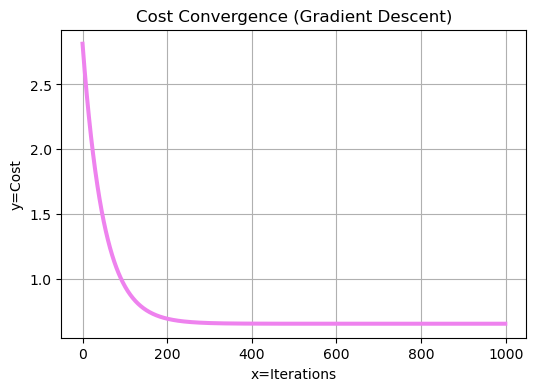

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(cost_history, color="violet", linewidth=2.9)
plt.xlabel("x=Iterations")
plt.ylabel("y=Cost")
plt.title("Cost Convergence (Gradient Descent)")
plt.grid(True)
plt.show()